In [15]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [16]:
with fits.open('data/flat.fits') as hdul:
    hdul.info()
    flat_data = hdul[0].data
    print(f"\nFlat shape: {flat_data.shape}")
    print(f"Flat dtype: {flat_data.dtype}")

with fits.open('data/moon.fits') as hdul:
    hdul.info()
    moon_data = hdul[0].data
    print(f"\nMoon shape: {moon_data.shape}")

Filename: data/flat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (385, 4112)   float64   

Flat shape: (4112, 385)
Flat dtype: >f8
Filename: data/moon.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (385, 4112)   float64   

Moon shape: (4112, 385)


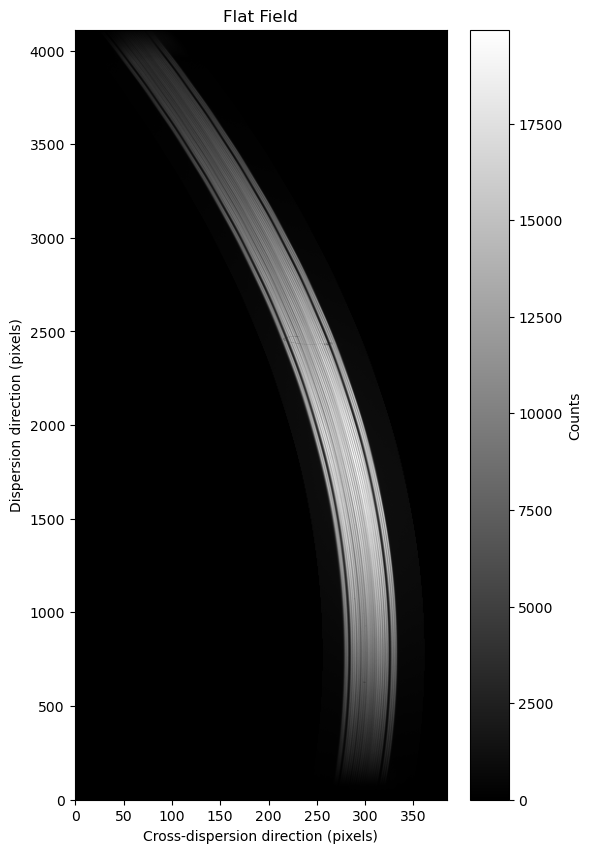

In [17]:
plt.figure(figsize=(6, 10))
plt.imshow(flat_data, aspect='auto', origin='lower', cmap='gray')
plt.colorbar(label='Counts')
plt.xlabel('Cross-dispersion direction (pixels)')
plt.ylabel('Dispersion direction (pixels)')
plt.title('Flat Field')
plt.show()

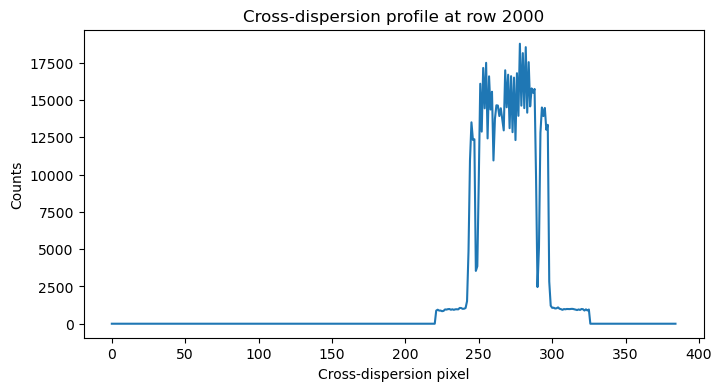

In [18]:
row = 2000  # a representative middle row
profile = flat_data[row, :]

plt.figure(figsize=(8, 4))
plt.plot(profile)
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Counts')
plt.title(f'Cross-dispersion profile at row {row}')
plt.show()

In [19]:
threshold_frac = 0.3  # 30% of peak, above background
background = np.median(profile[:100])  # background level from clearly empty pixels
peak = profile.max()
threshold = background + threshold_frac * (peak - background)

above_threshold = profile > threshold
indices_above = np.where(above_threshold)[0]

left_edge = indices_above.min()
right_edge = indices_above.max()

print(f"Background level: {background:.1f}")
print(f"Peak level: {peak:.1f}")
print(f"Threshold: {threshold:.1f}")
print(f"Left tramline (row {row}): pixel {left_edge}")
print(f"Right tramline (row {row}): pixel {right_edge}")

Background level: 0.0
Peak level: 18780.0
Threshold: 5634.0
Left tramline (row 2000): pixel 244
Right tramline (row 2000): pixel 297


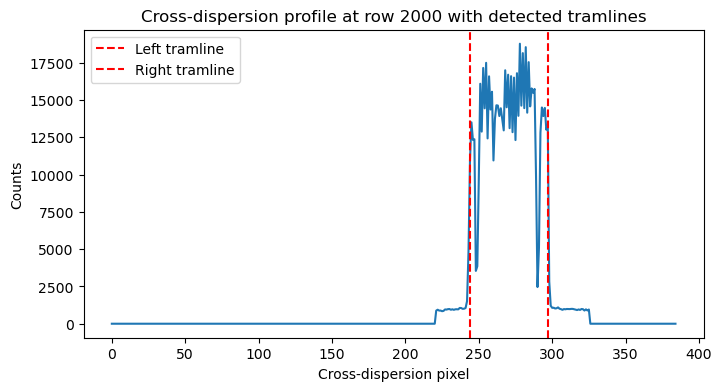

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(profile)
plt.axvline(left_edge, color='red', linestyle='--', label='Left tramline')
plt.axvline(right_edge, color='red', linestyle='--', label='Right tramline')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Counts')
plt.title(f'Cross-dispersion profile at row {row} with detected tramlines')
plt.legend()
plt.show()

In [21]:
n_rows = flat_data.shape[0]
left_tramline = np.full(n_rows, np.nan)
right_tramline = np.full(n_rows, np.nan)

for r in range(n_rows):
    profile = flat_data[r, :]
    background = np.median(profile[:50])
    peak = profile.max()

    if peak - background < 100:  # skip rows with no real signal
        continue

    threshold = background + threshold_frac * (peak - background)
    above_threshold = profile > threshold
    indices_above = np.where(above_threshold)[0]

    if len(indices_above) == 0:
        continue

    left_tramline[r] = indices_above.min()
    right_tramline[r] = indices_above.max()

valid = ~np.isnan(left_tramline)
print(f"Rows with detected tramlines: {valid.sum()} out of {n_rows}")

Rows with detected tramlines: 4057 out of 4112


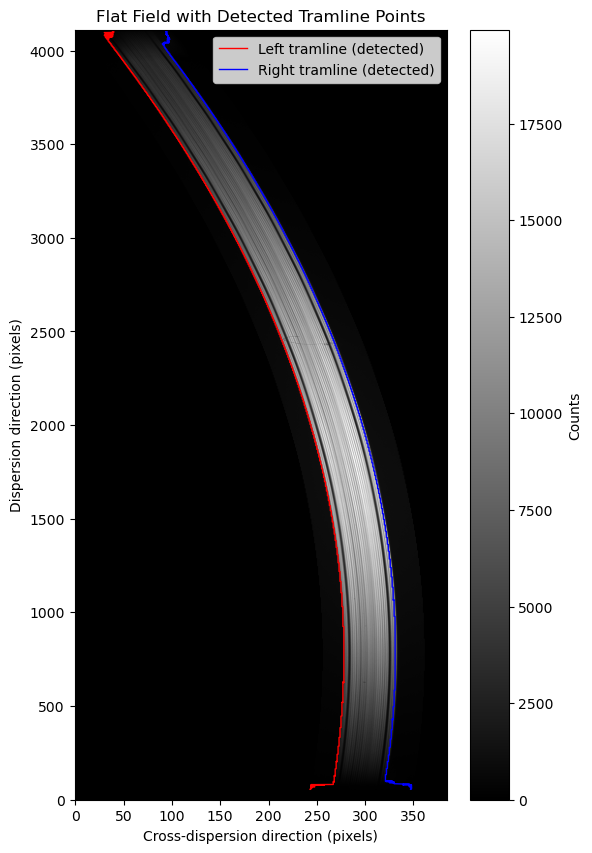

In [22]:
rows = np.arange(n_rows)

plt.figure(figsize=(6, 10))
plt.imshow(flat_data, aspect='auto', origin='lower', cmap='gray')
plt.plot(left_tramline, rows, 'r-', linewidth=1, label='Left tramline (detected)')
plt.plot(right_tramline, rows, 'b-', linewidth=1, label='Right tramline (detected)')
plt.xlabel('Cross-dispersion direction (pixels)')
plt.ylabel('Dispersion direction (pixels)')
plt.title('Flat Field with Detected Tramline Points')
plt.legend()
plt.colorbar(label='Counts')
plt.show()

In [23]:
   valid = ~np.isnan(left_tramline)
   rows_valid = rows[valid]

In [27]:
tramline_width = right_tramline[valid] - left_tramline[valid]
print(f"Tramline separation - mean: {tramline_width.mean():.2f}, std: {tramline_width.std():.2f}")
print(f"Min: {tramline_width.min():.2f}, Max: {tramline_width.max():.2f}")

Tramline separation - mean: 53.82, std: 4.14
Min: 51.00, Max: 104.00


In [28]:
outlier_idx = np.argmax(tramline_width)
outlier_row = rows_valid[outlier_idx]
print(f"Outlier at row: {outlier_row}, width: {tramline_width[outlier_idx]:.2f}")

Outlier at row: 53, width: 104.00


Median tramline width: 53.00 pixels


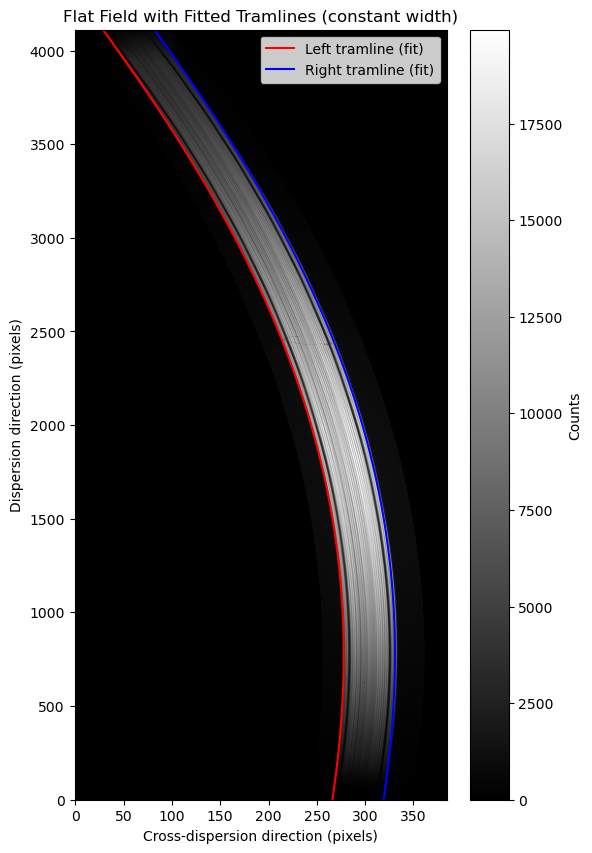

In [32]:
poly_order = 4
center_points = (left_tramline + right_tramline) / 2
width_median = np.median(tramline_width)

center_coeffs = np.polyfit(rows_valid, center_points[valid], poly_order)
center_fit = np.polyval(center_coeffs, rows)

left_fit_v2 = center_fit - width_median / 2
right_fit_v2 = center_fit + width_median / 2

print(f"Median tramline width: {width_median:.2f} pixels")

plt.figure(figsize=(6, 10))
plt.imshow(flat_data, aspect='auto', origin='lower', cmap='gray')
plt.plot(left_fit_v2, rows, 'r-', linewidth=1.5, label='Left tramline (fit)')
plt.plot(right_fit_v2, rows, 'b-', linewidth=1.5, label='Right tramline (fit)')
plt.xlabel('Cross-dispersion direction (pixels)')
plt.ylabel('Dispersion direction (pixels)')
plt.title('Flat Field with Fitted Tramlines (constant width)')
plt.legend()
plt.colorbar(label='Counts')
plt.savefig('figures/tramlines_fitted.png', dpi=150)
plt.show()

## Point 1: Determine the tramlines

